In [1]:
# Imports
import sys
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

In [2]:
# CD-NLGSSM imports
from cd_dynamax.src.utils.experiment_utils import *
from cd_dynamax.src.utils.simulation_utils import filter_and_forecast
sys.path.append("..")
# Demo plotting import
from demo_plot_filter_forecast import (
    plot_filter_then_forecast_state_results,
)


## Define the Lorenz 63 Model


We generate data from a Lorenz 63 system, from dynamics with the following stochastic differential equations:

\begin{align*}
\frac{d x}{d t} &= a(y-x) + \sigma w_x(t) \\
\frac{d y}{d t} &= x(b-z) - y + \sigma w_y(t) \\
\frac{d z}{d t} &= xy - cz + \sigma w_z(t),
\end{align*}

With parameters $a=10, b=28, c=8/3$, the system gives rise to chaotic behavior, and we choose $\sigma=1.0$ for diffusion.

To generate data, we numerically approximate random path solutions to this SDE using Heun's method (i.e. improved Euler), as implemented in [Diffrax](https://docs.kidger.site/diffrax/api/solvers/sde_solvers/).


We assume the observation model is
\begin{align*}
y(t) &= H x(t) + r(t) \\
r(t) &\sim N(0,R),
\end{align*}
where we choose $R=I$. 

Namely, **we impose partial observability with H=[1, 0, 0]**, with noisy observations, sampled at irregular time intervals.

In [3]:
# Default Lorenz 63 parameter definition in config file
# where only the first component (x_1) is observed
default_lorenz63_config_model = "../configs/model/l63_x1_filter"

In [4]:
# Specify true Lorenz '63 parameters
from cd_dynamax.src.utils.physics_based_models import LearnableLorenz63_Drift

# Define the True Lorenz 63 Model parameters dictionary
true_model_def = {
    'initial_values.dynamics_drift': {
        "params": LearnableLorenz63_Drift(
            sigma=10.0,
            rho=28.0,
            beta=8.0 / 3.0
        ),
        "props": None # Let us use the default parameter properties
    }
}


In [5]:
# Create and initialize the CD-NLGSSM model
true_model, true_params, true_props = create_cdnlgssm_model_from_config(
    true_model_config_file=default_lorenz63_config_model,
    overrides=true_model_def,
)

### Simulate data using true CDNLGSSM model

In [6]:
from cd_dynamax import make_key_sequence
from cd_dynamax.src.utils.demo_utils import sample_t_emissions

keys = make_key_sequence(0)
t_emissions = sample_t_emissions(
    start=0.0,
    stop=50.0,
    dt=0.01,
    regular=False,
    key=next(keys)
)

# Simulate data using true parameters (observed at times t_emissions)
# Note that default SDE diffeqsolve settings solve using dfx.Heun() with dfx.ConstantStepSize() and dt0=0.01 step size.
states, emissions = true_model.sample(
    params=true_params,
    key=next(keys),
    num_timesteps=len(t_emissions),
    t_emissions=t_emissions,
    transition_type="path",
)

[make_t_emissions] Generated 5000 points from 0.0 to 50.0 with avg step ~0.0100
[make_t_emissions] Smallest time step = 0.000004
Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.
Sampling from continuous-discrete non-linear Gaussian SSM path


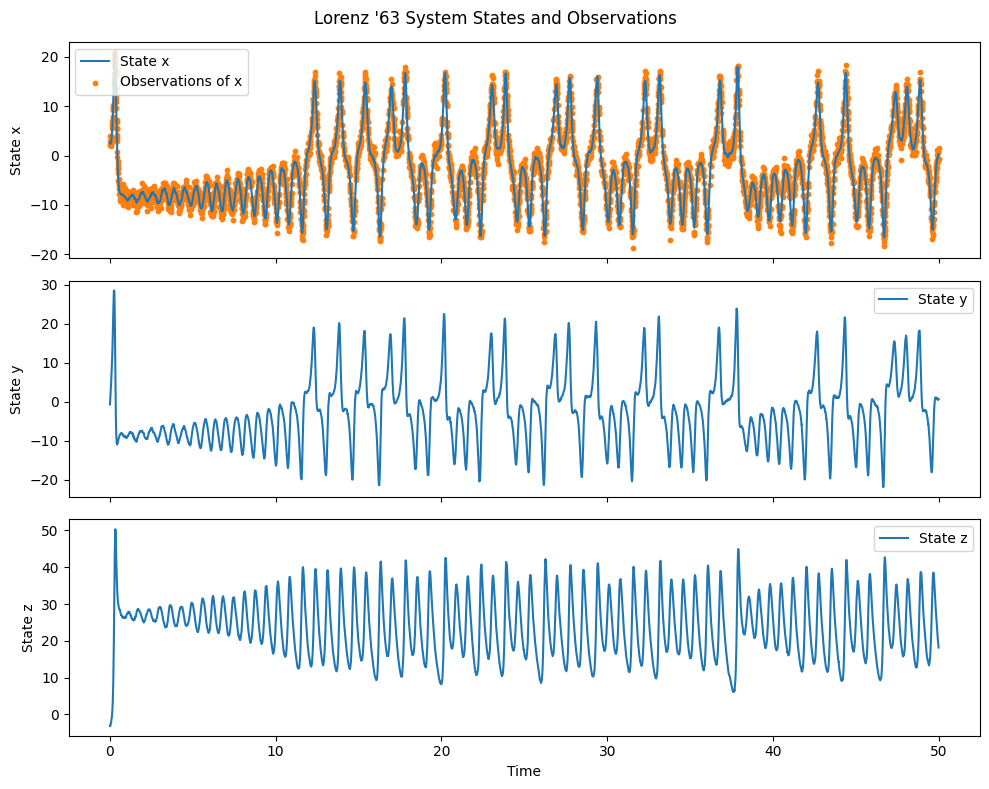

In [7]:
# Plot the results in a subplot with 3 rows, with observations overlaid in first emission_dims rows
fig, axs = plt.subplots(
    true_model.state_dim,
    1,
    figsize=(10, 8),
    sharex=True
)
state_labels = ['x', 'y', 'z']

for i in range(true_model.state_dim):
    axs[i].plot(
        t_emissions, states[:, i],
        label=f'State {state_labels[i]}',
        color='C0'
    )
    if i < true_model.emission_dim:
        axs[i].scatter(
            t_emissions,
            emissions[:, i],
            label=f'Observations of {state_labels[i]}',
            color='C1',
            s=10
        )
    axs[i].legend()
    axs[i].set_ylabel(f'State {state_labels[i]}')
axs[-1].set_xlabel('Time')
plt.suptitle('Lorenz \'63 System States and Observations')
plt.tight_layout()
plt.show()

## Filtering and forecasting

In [8]:
# Assign forecasting and filtering time indices based on T_filter fraction.
T_filter=0.95
T0 = t_emissions[0]
T_forecast_end = t_emissions[-1]
T_filter_end = T0 + T_filter * (T_forecast_end - T0)

### Extended Kalman Filter (EKF)

In [9]:
# Default EKF settings are defined in config file
default_ekf_config = "../configs/filter/ekf_StateFirst_EmissionsFirst"

In [10]:
# Figure-out the filtering/smoothing settings from config
ekf_hyperparams, ekf_info = create_cdnlgssm_filter_from_config(
    default_ekf_config,
    overrides={}
)

In [11]:
print("Running filtering with {filter_name} from T={T0} up to T={T_filter_end} and forecasting up to T={T_forecast_end}.".format(
    filter_name = ekf_info['name'] if ekf_info is not None and 'name' in ekf_info else "the specified filter",
    T0=T0, T_filter_end=T_filter_end, T_forecast_end=T_forecast_end
    )
)

# Perform filtering and forecasting
ekf_filtered, ekf_forecasted, start_idx_filter, stop_idx_filter, start_idx_forecast, stop_idx_forecast = filter_and_forecast(
    model_params=true_params,
    filter_hyperparams=ekf_hyperparams,
    t_emissions=t_emissions,
    emissions=emissions,
    T0=T0,
    T_filter_end=T_filter_end,
    T_forecast_end=T_forecast_end,
)

Running filtering with EKF (1st order) from T=[0.00279298] up to T=[47.48812867] and forecasting up to T=[49.98735687].


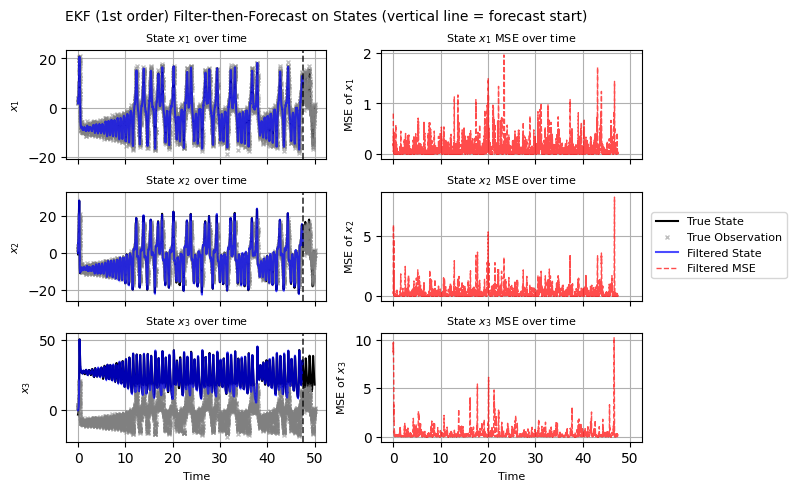

In [12]:
# Plot only the filtering results
plot_filter_then_forecast_state_results(
    data={
        'states': states,
        'emissions': emissions,
        't_emissions': t_emissions,
    },
    results={
        'filtered': tree_to_dict(ekf_filtered),
        'start_idx_filter': start_idx_filter,
        'stop_idx_filter': stop_idx_filter,
        'start_idx_forecast': start_idx_forecast,
        'stop_idx_forecast': stop_idx_forecast,
    },
    results_file=None, # Plot here, not save
    filter_info=ekf_info,
    plot_uncertainty=True,
    plot_observations=True,
    plot_mse=True,
)

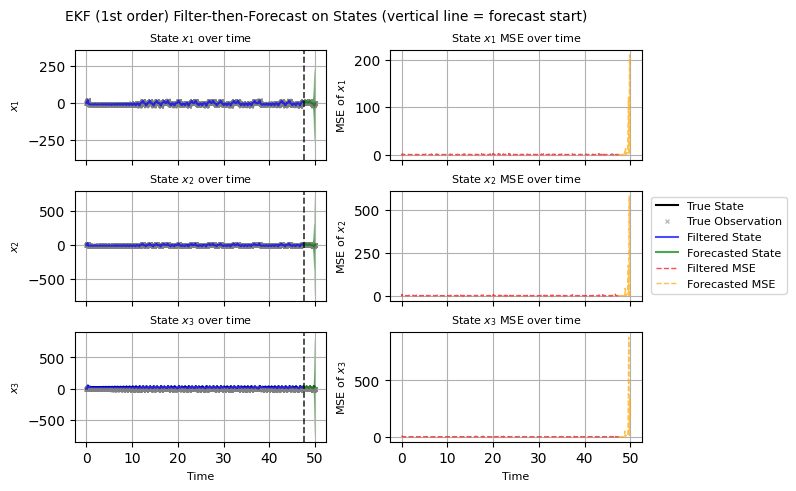

In [13]:
# Plot both filtering and forecasting results
plot_filter_then_forecast_state_results(
    data={
        'states': states,
        'emissions': emissions,
        't_emissions': t_emissions,
    },
    results={
        'filtered': tree_to_dict(ekf_filtered),
        'forecasted': tree_to_dict(ekf_forecasted),
        'start_idx_filter': start_idx_filter,
        'stop_idx_filter': stop_idx_filter,
        'start_idx_forecast': start_idx_forecast,
        'stop_idx_forecast': stop_idx_forecast,
    },
    results_file=None, # Plot here, not save
    filter_info=ekf_info,
    plot_uncertainty=True,
    plot_observations=True,
    plot_mse=True,
)

### Unscented Kalman Filter (EKF)

In [14]:
# Default UKF settings are defined in config file
default_ukf_config = "../configs/filter/ukf_StateFirst"

In [15]:
# Figure-out the filtering/smoothing settings from config
ukf_hyperparams, ukf_info = create_cdnlgssm_filter_from_config(
    default_ukf_config,
    overrides={}
)

In [16]:
print("Running filtering with {filter_name} from T={T0} up to T={T_filter_end} and forecasting up to T={T_forecast_end}.".format(
    filter_name = ekf_info['name'] if ekf_info is not None and 'name' in ekf_info else "the specified filter",
    T0=T0, T_filter_end=T_filter_end, T_forecast_end=T_forecast_end
    )
)

# Perform filtering and forecasting
ukf_filtered, ukf_forecasted, start_idx_filter, stop_idx_filter, start_idx_forecast, stop_idx_forecast = filter_and_forecast(
    model_params=true_params,
    filter_hyperparams=ukf_hyperparams,
    t_emissions=t_emissions,
    emissions=emissions,
    T0=T0,
    T_filter_end=T_filter_end,
    T_forecast_end=T_forecast_end,
)

Running filtering with EKF (1st order) from T=[0.00279298] up to T=[47.48812867] and forecasting up to T=[49.98735687].


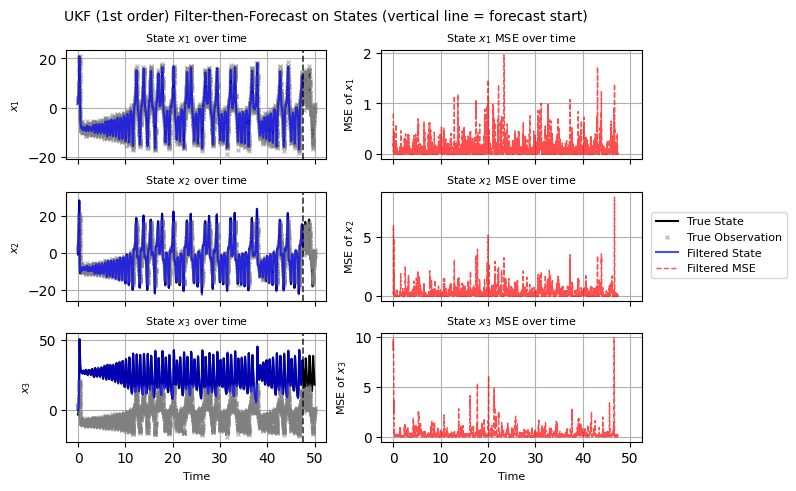

In [17]:
# Plot only the filtering results
plot_filter_then_forecast_state_results(
    data={
        'states': states,
        'emissions': emissions,
        't_emissions': t_emissions,
    },
    results={
        'filtered': tree_to_dict(ukf_filtered),
        'start_idx_filter': start_idx_filter,
        'stop_idx_filter': stop_idx_filter,
        'start_idx_forecast': start_idx_forecast,
        'stop_idx_forecast': stop_idx_forecast,
    },
    results_file=None, # Plot here, not save
    filter_info=ukf_info,
    plot_uncertainty=True,
    plot_observations=True,
    plot_mse=True,
)

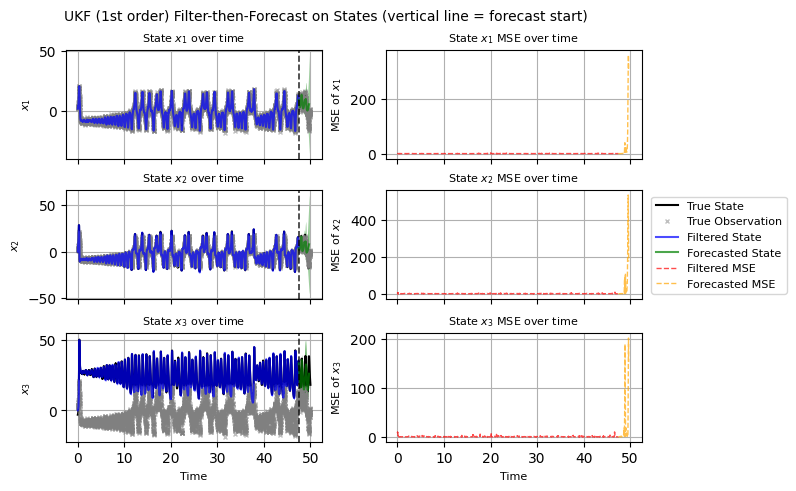

In [18]:
# Plot both filtering and forecasting results
plot_filter_then_forecast_state_results(
    data={
        'states': states,
        'emissions': emissions,
        't_emissions': t_emissions,
    },
    results={
        'filtered': tree_to_dict(ukf_filtered),
        'forecasted': tree_to_dict(ukf_forecasted),
        'start_idx_filter': start_idx_filter,
        'stop_idx_filter': stop_idx_filter,
        'start_idx_forecast': start_idx_forecast,
        'stop_idx_forecast': stop_idx_forecast,
    },
    results_file=None, # Plot here, not save
    filter_info=ukf_info,
    plot_uncertainty=True,
    plot_observations=True,
    plot_mse=True,
)

### Ensemble Kalman Filter (EnKF)

In [19]:
# Default EnKF settings are defined in config file
default_enkf_config = "../configs/filter/enkf_StateFirst"

In [20]:
# Figure-out the filtering/smoothing settings from config
enkf_hyperparams, enkf_info = create_cdnlgssm_filter_from_config(
    default_enkf_config,
    overrides={}
)

In [21]:
print("Running filtering with {filter_name} from T={T0} up to T={T_filter_end} and forecasting up to T={T_forecast_end}.".format(
    filter_name = ekf_info['name'] if ekf_info is not None and 'name' in ekf_info else "the specified filter",
    T0=T0, T_filter_end=T_filter_end, T_forecast_end=T_forecast_end
    )
)

# Perform filtering and forecasting
enkf_filtered, enkf_forecasted, start_idx_filter, stop_idx_filter, start_idx_forecast, stop_idx_forecast = filter_and_forecast(
    model_params=true_params,
    filter_hyperparams=enkf_hyperparams,
    t_emissions=t_emissions,
    emissions=emissions,
    T0=T0,
    T_filter_end=T_filter_end,
    T_forecast_end=T_forecast_end,
)

Running filtering with EKF (1st order) from T=[0.00279298] up to T=[47.48812867] and forecasting up to T=[49.98735687].


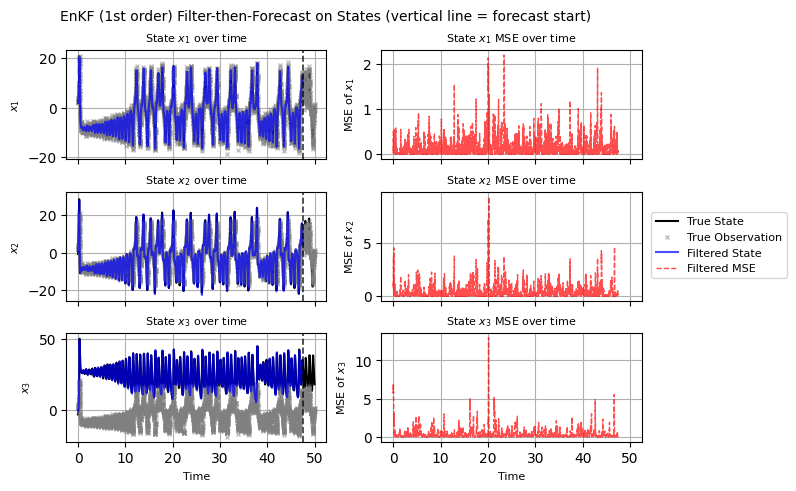

In [22]:
# Plot only the filtering results
plot_filter_then_forecast_state_results(
    data={
        'states': states,
        'emissions': emissions,
        't_emissions': t_emissions,
    },
    results={
        'filtered': tree_to_dict(enkf_filtered),
        'start_idx_filter': start_idx_filter,
        'stop_idx_filter': stop_idx_filter,
        'start_idx_forecast': start_idx_forecast,
        'stop_idx_forecast': stop_idx_forecast,
    },
    results_file=None, # Plot here, not save
    filter_info=enkf_info,
    plot_uncertainty=True,
    plot_observations=True,
    plot_mse=True,
)

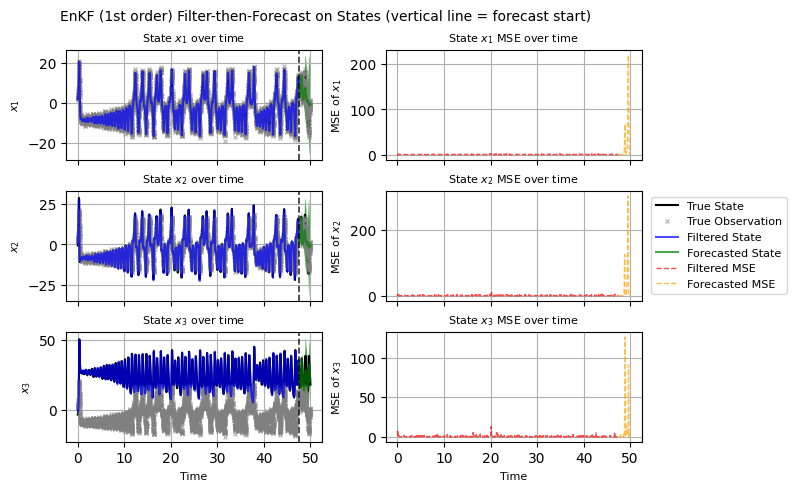

In [23]:
# Plot both filtering and forecasting results
plot_filter_then_forecast_state_results(
    data={
        'states': states,
        'emissions': emissions,
        't_emissions': t_emissions,
    },
    results={
        'filtered': tree_to_dict(enkf_filtered),
        'forecasted': tree_to_dict(enkf_forecasted),
        'start_idx_filter': start_idx_filter,
        'stop_idx_filter': stop_idx_filter,
        'start_idx_forecast': start_idx_forecast,
        'stop_idx_forecast': stop_idx_forecast,
    },
    results_file=None, # Plot here, not save
    filter_info=enkf_info,
    plot_uncertainty=True,
    plot_observations=True,
    plot_mse=True,
)